<a href="https://colab.research.google.com/github/Rudra-CSER/Ai-Education_analyzer_model/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  COMPLETE DATASET  (re-transposed: 10 countries × 23 features)
       country  pisa_score  exam_frequency  student_stress  academic_pressure  private_tutoring  mental_health_focus  teacher_quality  teacher_selection  training_model  career_structure  teacher_retention  learning_outcomes  dominant_assessment  coursework_weight  project_based_learning  creativity_evaluation  stress_impact  skill_development_focus  industry_alignment  vocational_prestige  skill_readiness  career_guidance  workforce_guidance
       Finland           7               2               2                  2                 1                    9                9                 10               9                 9                  9                  8                    8                  9                       9                      9              2                        9                   8                    8                8                9                   8
     Singapore          10               

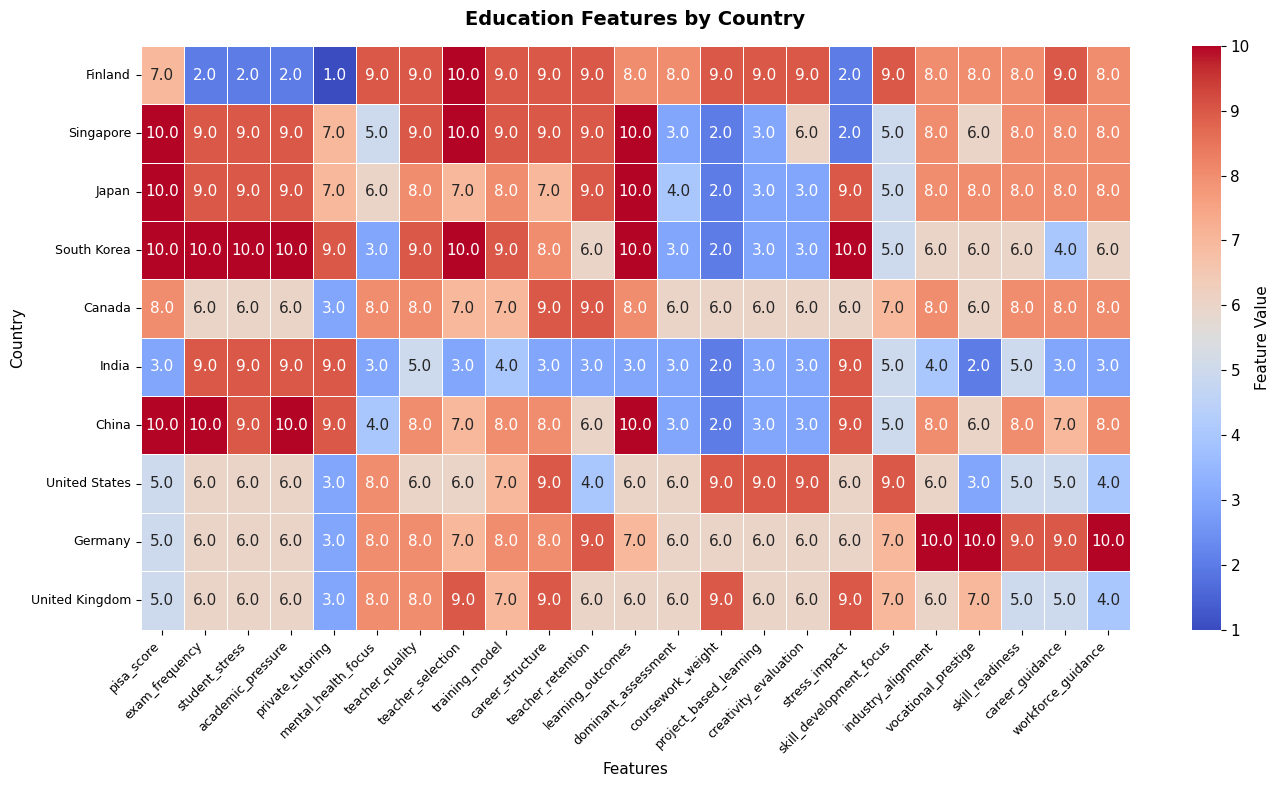

Saved: fig1_country_feature_heatmap.png


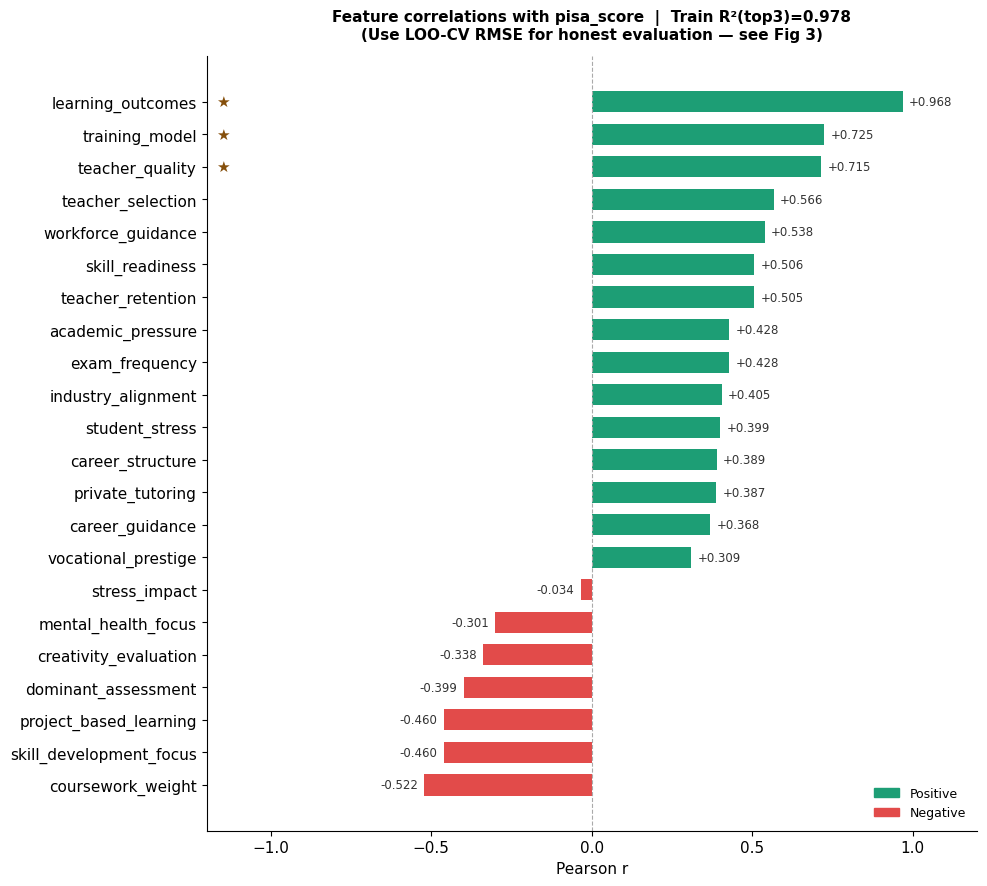

Saved: fig2_pisa_bar.png


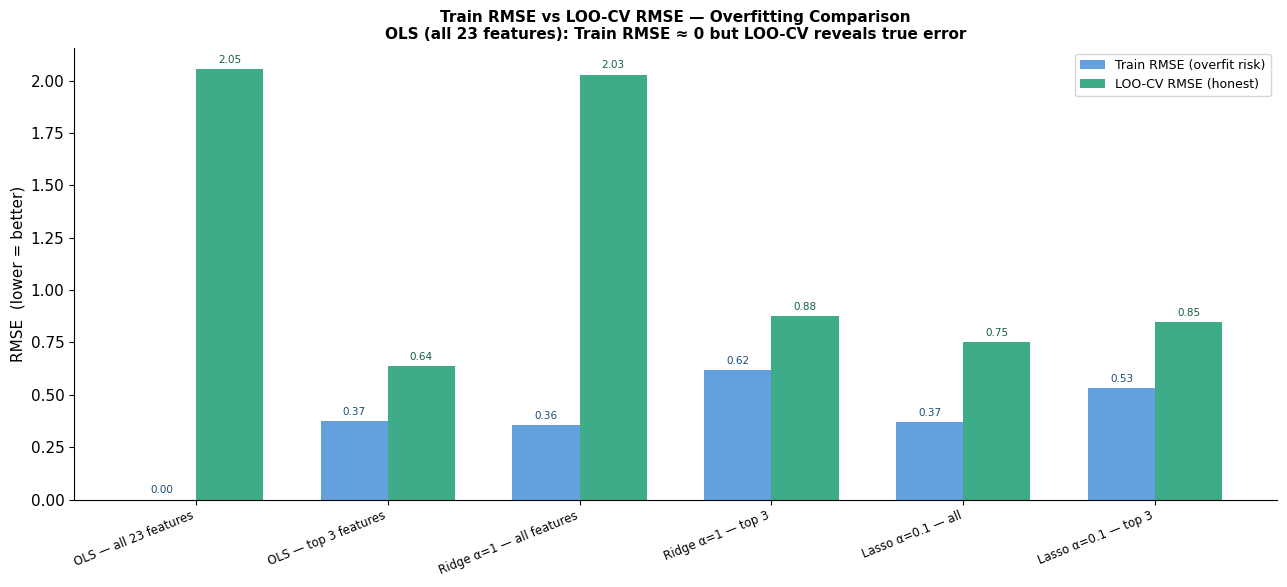

Saved: fig3_model_comparison.png


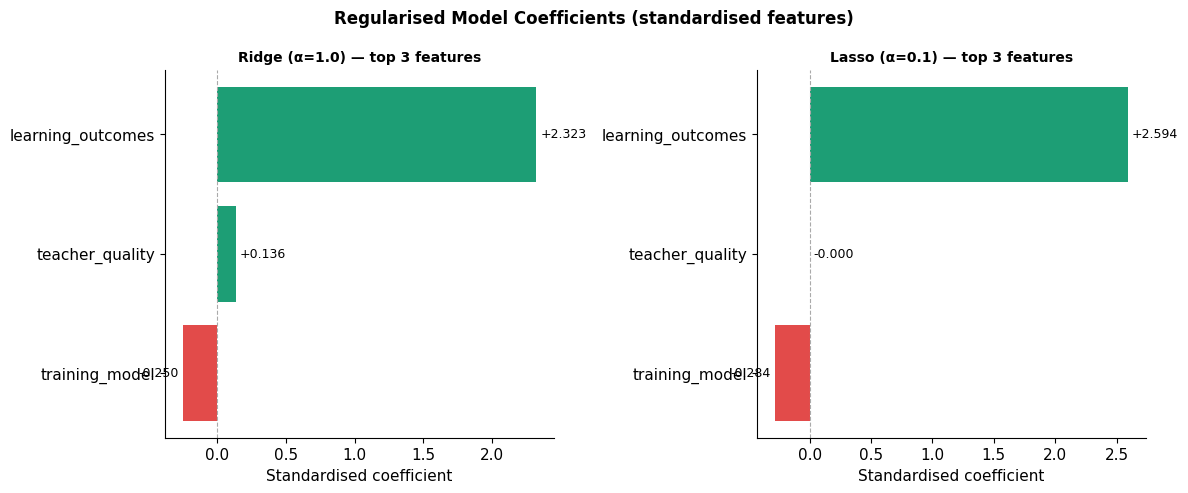

Saved: fig4_regularised_coefs.png


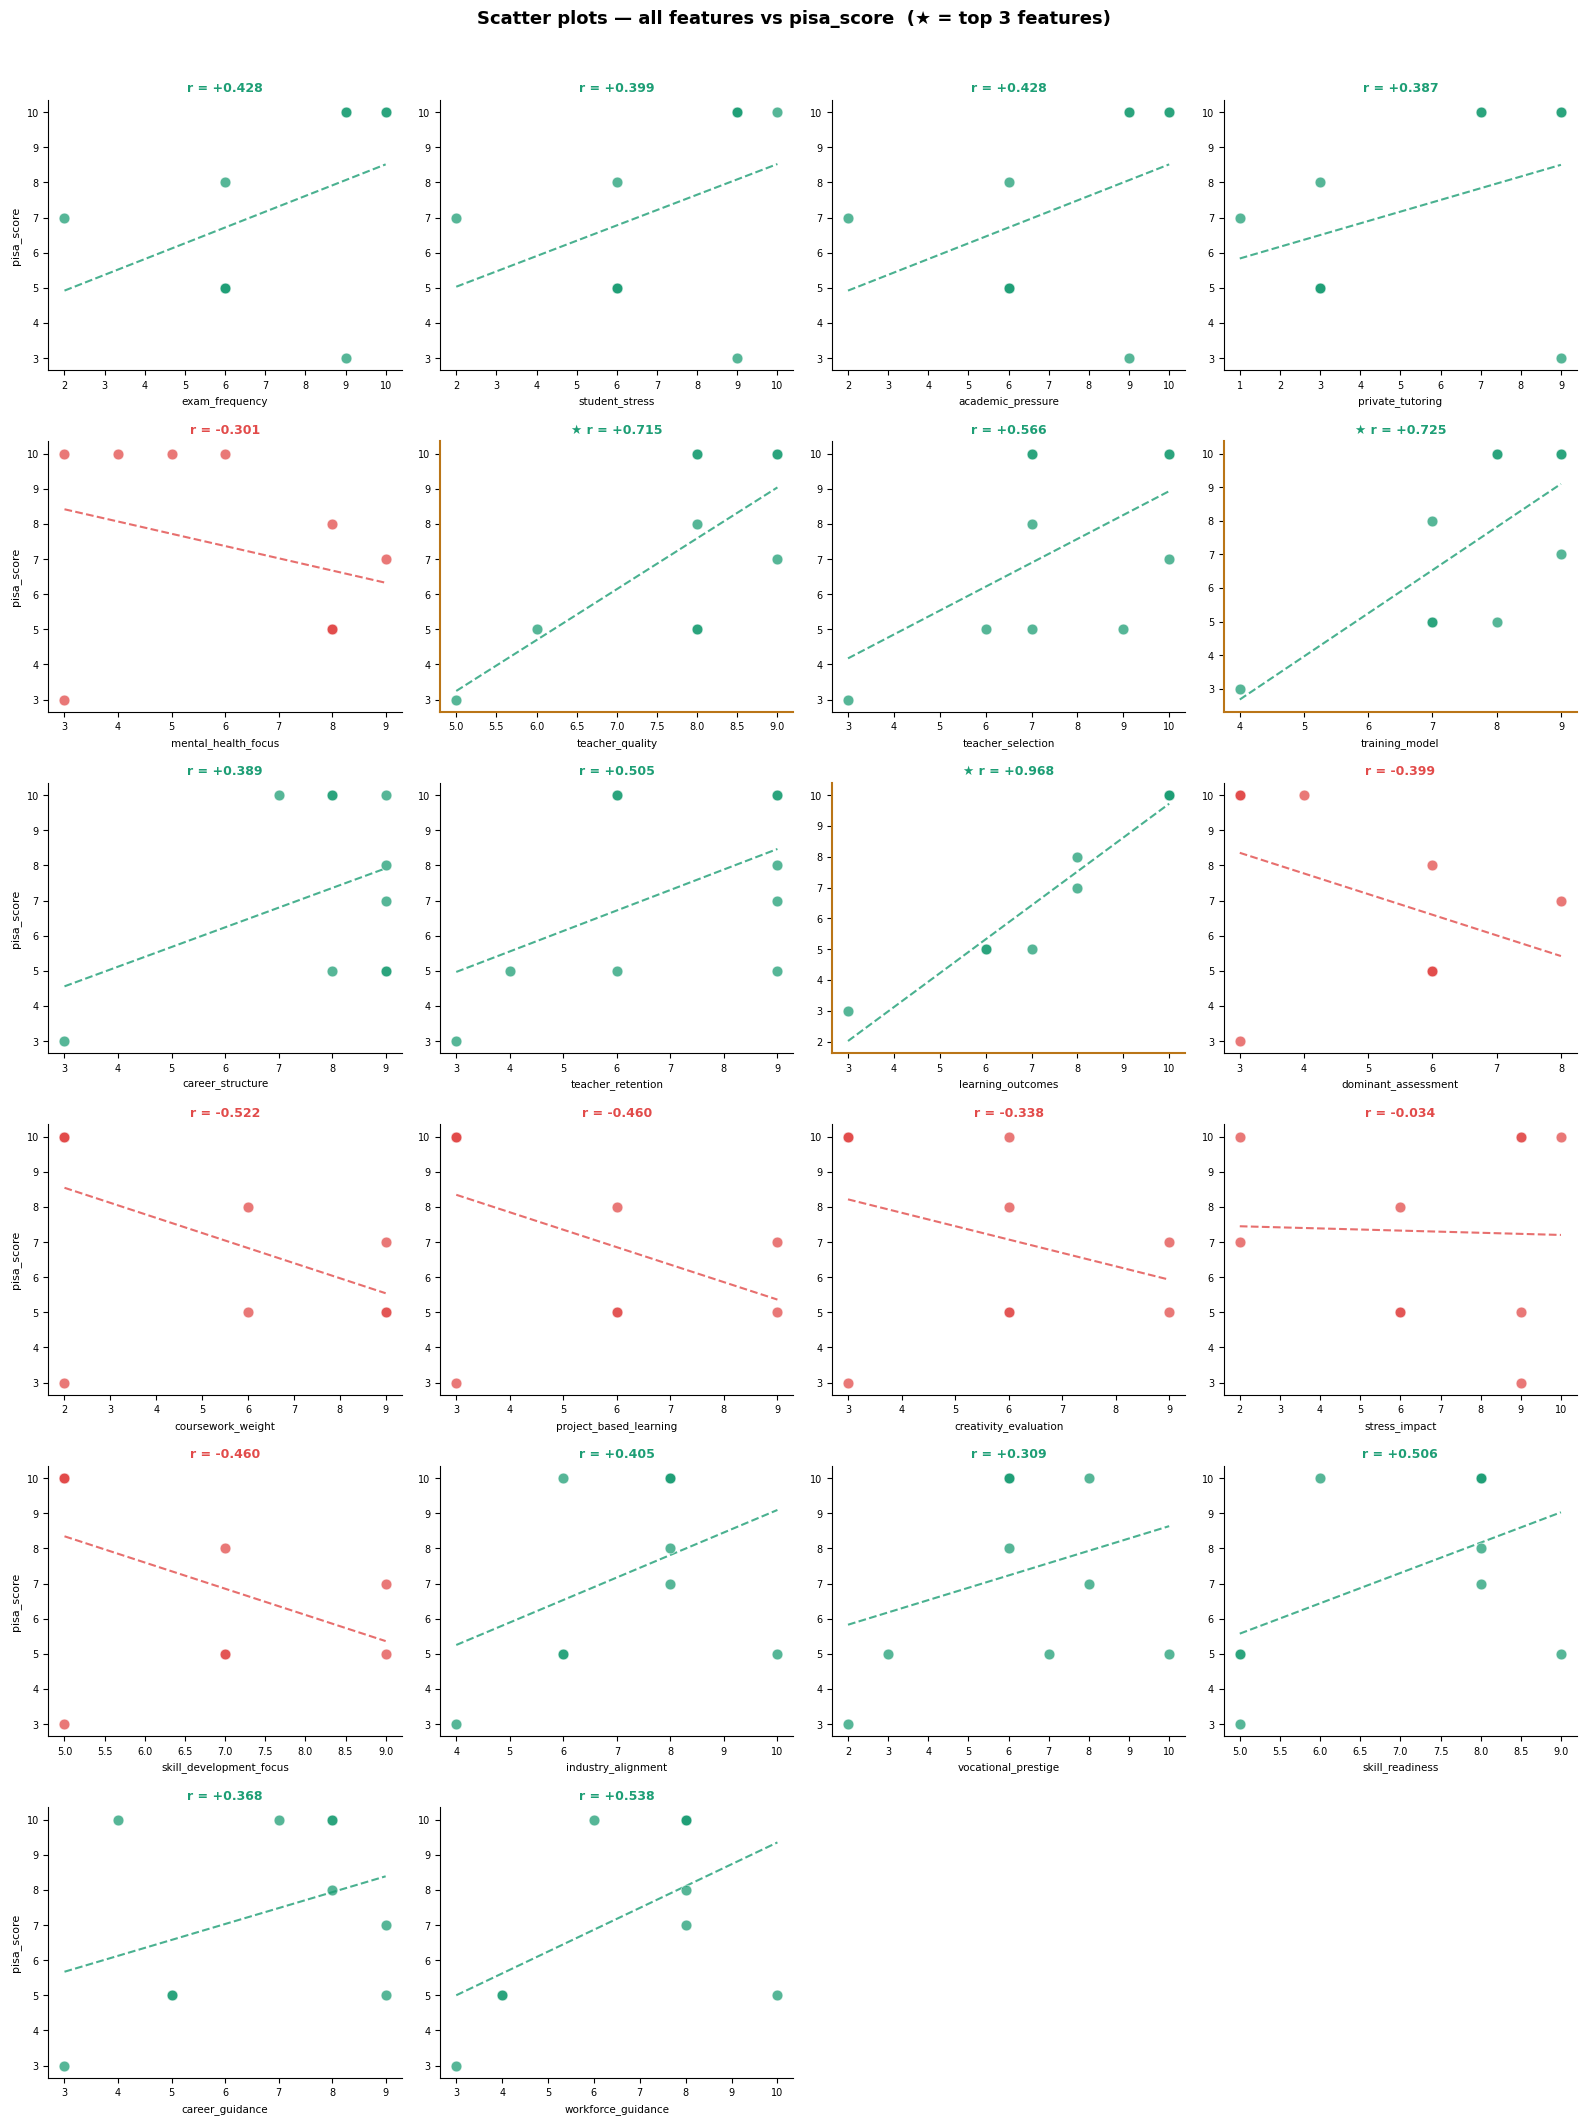

Saved: fig5_scatterplots.png

✅ Done. Required: pandas, numpy, matplotlib, seaborn, scipy, scikit-learn


In [32]:
# =============================================================================
# Correlation Analysis & Linear Regression — Combined Education Dataset
# Source         : combined_education_transposed.csv
#                  (features as rows × countries as columns → re-transposed on load)
# Target variable: pisa_score
# Top 3 features : learning_outcomes, training_model, teacher_quality
# Overfitting fix: Ridge/Lasso regularisation + LOO-CV RMSE evaluation
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. Load & re-transpose data
# -----------------------------------------------------------------------------
# File is stored as: feature | Finland | Singapore | ... (23 rows × 11 cols)
# We need:          country  | feature1 | feature2 | ... (10 rows × 24 cols)

df_raw = pd.read_csv("combined_education_transposed.csv")
df_raw.columns = df_raw.columns.str.strip()

# Re-transpose: features → columns, countries → rows
df = df_raw.set_index("feature").T
df.index.name = "country"
df.reset_index(inplace=True)
df.columns = df.columns.str.strip()

# Ensure all feature columns are numeric
for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(df[col])

pd.set_option("display.max_rows",     None)
pd.set_option("display.max_columns",  None)
pd.set_option("display.width",        None)
pd.set_option("display.max_colwidth", None)

print("\n" + "="*75)
print("  COMPLETE DATASET  (re-transposed: 10 countries × 23 features)")
print("="*75)
print(df.to_string(index=False))
print("="*75)
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("="*75 + "\n")

numeric  = df.drop(columns=["country"])
corr     = numeric.corr()
TARGET   = "pisa_score"
FEATURES = [c for c in numeric.columns if c != TARGET]

# Top 3 features by absolute Pearson |r| with pisa_score:
#   1. learning_outcomes  r = +0.9683  (strongest predictor)
#   2. training_model     r = +0.7245  (teacher training quality)
#   3. teacher_quality    r = +0.7147  (teacher expertise)
TOP3 = ["learning_outcomes", "training_model", "teacher_quality"]

# -----------------------------------------------------------------------------
# 2. WHY OVERFITTING HAPPENS HERE
# -----------------------------------------------------------------------------
# Dataset: 10 rows, 23 features → OLS perfectly memorises training data.
# Train R² = 1.0, but the model is completely useless on new data.
#
# Fixes applied:
#   (a) LOO-CV RMSE  — honest generalisation metric for tiny datasets
#                      (R² is undefined with 1 test sample, RMSE is not)
#   (b) Ridge / Lasso regularisation — penalise model complexity
#   (c) Prefer top-3 feature model over full feature model
#   (d) StandardScaler — required before Ridge / Lasso

X_all = numeric[FEATURES].values
X_top = numeric[TOP3].values
y     = numeric[TARGET].values

scaler_all = StandardScaler();  X_all_s = scaler_all.fit_transform(X_all)
scaler_top = StandardScaler();  X_top_s = scaler_top.fit_transform(X_top)

# -----------------------------------------------------------------------------
# 3. LOO-CV RMSE helper
# -----------------------------------------------------------------------------
def loo_rmse(model, X, y):
    """Leave-One-Out cross-validated RMSE — best CV for n=10."""
    preds = np.zeros(len(y))
    for train_idx, test_idx in LeaveOneOut().split(X):
        model.fit(X[train_idx], y[train_idx])
        preds[test_idx] = model.predict(X[test_idx])
    return np.sqrt(mean_squared_error(y, preds))

def train_rmse(model, X, y):
    model.fit(X, y)
    return np.sqrt(mean_squared_error(y, model.predict(X)))

# -----------------------------------------------------------------------------
# 4. Model comparison
# -----------------------------------------------------------------------------
configs = [
    ("OLS — all 23 features",    LinearRegression(),                    X_all_s),
    ("OLS — top 3 features",     LinearRegression(),                    X_top_s),
    ("Ridge α=1 — all features", Ridge(alpha=1.0),                      X_all_s),
    ("Ridge α=1 — top 3",        Ridge(alpha=1.0),                      X_top_s),
    ("Lasso α=0.1 — all",        Lasso(alpha=0.1, max_iter=10000),      X_all_s),
    ("Lasso α=0.1 — top 3",      Lasso(alpha=0.1, max_iter=10000),      X_top_s),
]

print(f"\n{'Model':<35} {'Train RMSE':>12}  {'LOO-CV RMSE':>13}")
print("="*62)
rmse_data = []
for name, model, Xm in configs:
    tr  = train_rmse(model, Xm.copy(), y)
    loo = loo_rmse(model,   Xm.copy(), y)
    rmse_data.append((name, tr, loo))
    flag = "  ← OVERFIT ✗" if tr < 0.01 else ("  ← BEST ✓" if loo == min(r[2] for r in rmse_data) else "")
    print(f"{name:<35} {tr:>12.4f}  {loo:>13.4f}{flag}")
print("="*62)
print("Lower RMSE = better.  LOO-CV RMSE is the only honest estimate.\n")

r2_red = r2_score(y, LinearRegression().fit(X_top_s, y).predict(X_top_s))
print(f"Train R² — OLS top-3 (reference only, NOT for evaluation): {r2_red:.4f}")
print("NOTE: Train R² of full OLS model = 1.000 → classic overfit.\n")

# -----------------------------------------------------------------------------
# 5. Shared plot style
# -----------------------------------------------------------------------------
cmap = sns.diverging_palette(10, 150, as_cmap=True)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size": 11,
})

# =============================================================================
# FIGURE 1 — Full Correlation Heatmap (24×24)
# =============================================================================
# =============================================================================
# FIGURE 1 — Country vs Feature Heatmap
# =============================================================================

# Set country as index so it appears on Y-axis
heatmap_data = df.set_index("country")

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Feature Value"},
    ax=ax
)

ax.set_title(
    "Education Features by Country",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Features", fontsize=11)
ax.set_ylabel("Country", fontsize=11)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("fig1_country_feature_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved: fig1_country_feature_heatmap.png")
# =============================================================================
# FIGURE 2 — Feature Correlations with pisa_score (Bar Chart)
# =============================================================================
pisa_corr  = corr[TARGET].drop(TARGET).sort_values()
colors_bar = ["#E24B4A" if v < 0 else "#1D9E75" for v in pisa_corr]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(pisa_corr.index, pisa_corr.values,
               color=colors_bar, edgecolor="none", height=0.65)
ax.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax.set_xlim(-1.2, 1.2)
ax.set_xlabel("Pearson r", fontsize=11)
ax.set_title(
    f"Feature correlations with {TARGET}  |  Train R²(top3)={r2_red:.3f}\n"
    "(Use LOO-CV RMSE for honest evaluation — see Fig 3)",
    fontsize=11, fontweight="bold", pad=12
)
for bar, val in zip(bars, pisa_corr.values):
    xpos = val + (0.02 if val >= 0 else -0.02)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8.5, color="#333")
for bar, feat in zip(bars, pisa_corr.index):
    if feat in TOP3:
        ax.text(-1.17, bar.get_y() + bar.get_height()/2,
                "★", va="center", ha="left", fontsize=11, color="#854F0B")
ax.legend(handles=[
    plt.Rectangle((0,0),1,1,color="#1D9E75",label="Positive"),
    plt.Rectangle((0,0),1,1,color="#E24B4A",label="Negative"),
], loc="lower right", fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig("fig2_pisa_bar.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: fig2_pisa_bar.png")

# =============================================================================
# FIGURE 3 — Train RMSE vs LOO-CV RMSE (Overfitting Comparison)
# =============================================================================
names   = [r[0] for r in rmse_data]
tr_rmse = [r[1] for r in rmse_data]
lo_rmse = [r[2] for r in rmse_data]

x = np.arange(len(names)); width = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width/2, tr_rmse, width, label="Train RMSE (overfit risk)",
            color="#4A90D9", alpha=0.85, edgecolor="none")
b2 = ax.bar(x + width/2, lo_rmse, width, label="LOO-CV RMSE (honest)",
            color="#1D9E75", alpha=0.85, edgecolor="none")
ax.set_ylabel("RMSE  (lower = better)")
ax.set_title(
    "Train RMSE vs LOO-CV RMSE — Overfitting Comparison\n"
    "OLS (all 23 features): Train RMSE ≈ 0 but LOO-CV reveals true error",
    fontsize=11, fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=22, ha="right", fontsize=8.5)
ax.legend(fontsize=9)
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7.5, color="#1a4a7a")
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7.5, color="#155f44")
plt.tight_layout()
plt.savefig("fig3_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: fig3_model_comparison.png")

# =============================================================================
# FIGURE 4 — Ridge vs Lasso Coefficients (top 3 features)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (ModelClass, alpha, title) in zip(axes, [
    (Ridge, 1.0, "Ridge (α=1.0) — top 3 features"),
    (Lasso, 0.1, "Lasso (α=0.1) — top 3 features"),
]):
    m = ModelClass(alpha=alpha, max_iter=10000)
    m.fit(X_top_s, y)
    coefs  = pd.Series(m.coef_, index=TOP3).sort_values()
    cols_c = ["#E24B4A" if v < 0 else "#1D9E75" for v in coefs]
    ax.barh(coefs.index, coefs.values, color=cols_c, edgecolor="none")
    ax.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
    for i, (feat, val) in enumerate(coefs.items()):
        ax.text(val + (0.03 if val >= 0 else -0.03), i, f"{val:+.3f}",
                va="center", ha="left" if val >= 0 else "right", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Standardised coefficient")
plt.suptitle("Regularised Model Coefficients (standardised features)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_regularised_coefs.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: fig4_regularised_coefs.png")

# =============================================================================
# FIGURE 5 — Scatter Plots: All Features vs pisa_score (6×4 grid)
# =============================================================================
ncols = 4
nrows = int(np.ceil(len(FEATURES) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax_i  = axes[i]
    x_s   = numeric[feat]
    r, _  = stats.pearsonr(x_s, y)
    color = "#1D9E75" if r >= 0 else "#E24B4A"

    ax_i.scatter(x_s, y, color=color, alpha=0.75,
                 edgecolors="white", linewidth=0.5, s=60, zorder=3)

    m, b = np.polyfit(x_s, y, 1)
    xs   = np.linspace(x_s.min(), x_s.max(), 100)
    ax_i.plot(xs, m*xs+b, color=color, linewidth=1.5, linestyle="--", alpha=0.8)

    if feat in TOP3:
        for spine in ax_i.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("#BA7517")
            spine.set_linewidth(1.5)

    ax_i.set_xlabel(feat, fontsize=7.5)
    ax_i.set_ylabel(TARGET if i % ncols == 0 else "", fontsize=8)
    ax_i.set_title(
        f"{'★ ' if feat in TOP3 else ''}r = {r:+.3f}",
        fontsize=9, color="#1D9E75" if r >= 0 else "#E24B4A", fontweight="bold"
    )
    ax_i.tick_params(labelsize=7)
    ax_i.spines["top"].set_visible(False)
    ax_i.spines["right"].set_visible(False)

for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"Scatter plots — all features vs {TARGET}  (★ = top 3 features)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("fig5_scatterplots.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("Saved: fig5_scatterplots.png")

print("\n✅ Done. Required: pandas, numpy, matplotlib, seaborn, scipy, scikit-learn")